# Chapter 3 (extra): Implicit solver on an expanding (non-uniform) grid

The concentration profile of a diffusion-controlled electrode reaction changes
most steeply right at the electrode surface and flattens out toward the bulk.
A **uniform** spatial grid wastes nodes far from the electrode (where almost
nothing happens) to resolve the surface region. Honeychurch's Chapter 3 fixes
this with an **exponentially expanding grid**: closely spaced nodes near the
surface, progressively coarser nodes toward the bulk.

The trick is a change of variable. Define a new coordinate $y$ such that
uniform steps in $y$ correspond to exponentially growing steps in the physical
distance $\chi$:

$$y = \ln(1 + a\,\chi), \qquad \chi = \frac{e^{y}-1}{a},$$

where $a$ is an adjustable **expansion factor**. Then
$$\frac{\partial y}{\partial \chi} = \frac{a}{1+a\chi} = a\,e^{-y}.$$

Rewriting Fick's second law $\partial_\tau c = \partial_{\chi\chi}c$ in $y$-space
(using $\partial_\chi = (\partial_\chi y)\partial_y$ twice) gives a
convection–diffusion-like equation with a **position-dependent** model diffusion
coefficient. After discretising on a uniform $y$-grid of spacing $\Delta y$ and
applying the fully implicit (backward-Euler) scheme, each interior node $p$ obeys

$$-D_p(1+\alpha)\,c_{p-1}^{k+1}
+\big(1+2D_p\big)c_{p}^{k+1}
-D_p(1-\alpha)\,c_{p+1}^{k+1}
= c_p^{k},$$

with
$$D_p = D_M\,e^{-2(p-1)\Delta y},\qquad \alpha=\frac{\Delta y}{2},\qquad
D_M=\frac{a^2 D\,\Delta\tau}{\Delta y^2}.$$

The $e^{-2(p-1)\Delta y}=e^{-2y_p}$ factor is the Jacobian of the transformation
squared (the $(\partial_\chi y)^2$ from the second derivative); the $\pm\alpha$
asymmetry is the first-derivative (drift) term. The matrix is still tridiagonal,
so the solver is only slightly more complex than the uniform implicit one, and it
reaches the same accuracy with **far fewer spatial nodes**.

This notebook re-implements the implicit expanding-grid solver
(`expandImplicit.nb` / `makeDiagonals`), validates it against the Cottrell
transient, and quantifies the node-count saving versus a uniform implicit grid.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import serm
from serm.grids import space_points
from serm.tridiagonal import tridiag_solve_banded

np.set_printoptions(precision=5, suppress=True)

In [2]:
from serm.sourcelinks import source_links
source_links(space_points, tridiag_solve_banded, serm.cottrell_dimensionless, serm.electrode_current)

## Grid sizing

The semi-infinite domain is truncated at six diffusion lengths,
$\chi_{\max}=6$, which in $y$-space is $y_{\max}=\ln(1+6a)$. With dimensionless
time step $\Delta\tau=1/(n-1)$ and the requirement $D_M=a^2 D\Delta\tau/\Delta y^2$,
the book sizes the grid as

$$m = 1 + \big\lceil \tfrac{y_{\max}}{a}\sqrt{D_M(n-1)}\big\rceil,
\qquad \Delta y = \frac{y_{\max}}{m-1},\qquad \alpha=\frac{\Delta y}{2}.$$

Because the $y$-grid is uniform with $y_p=(p-1)\Delta y$, the per-node diffusion
coefficient is $D_p = D_M e^{-2y_p}=D_M\exp\!\big[-2\tfrac{p-1}{m-1}y_{\max}\big]$.

In [3]:
def expanding_grid_params(D_M, n, a):
    """Sizing for the exponentially expanding grid (chapter3.nb / expandImplicit.nb).

    Returns (m, y_max, dy, alpha).  Bulk truncation chi_max = 6 -> y_max = ln(1+6a);
    m = 1 + ceil(y_max/a * sqrt(D_M (n-1))); dy = y_max/(m-1); alpha = dy/2.
    """
    y_max = np.log(1.0 + 6.0 * a)
    m = 1 + int(np.ceil(y_max / a * np.sqrt(D_M * (n - 1))))
    dy = y_max / (m - 1)
    alpha = dy / 2.0
    return m, y_max, dy, alpha

## The implicit expanding-grid solver

The three diagonals are built once from the position-dependent $D_p$. Only the
right-hand side changes per step: it is the previous concentration column, with
the last interior node receiving the bulk-boundary contribution
$D_{m-1}(1-\alpha)$ (the super-diagonal coefficient times $c_{\text{bulk}}=1$).

In [4]:
def expanding_implicit_solve(D_M, n, a):
    """Fully implicit solver on an exponentially expanding y-space grid.

    Port of makeDiagonals / implicitVarSolve2 from expandImplicit.nb.  Potential
    step to the diffusion limit for O + e- <-> R: surface c = 0, bulk c = 1,
    initial c = 1.  Returns (c, m, y_max) with c of shape (m, n).
    """
    m, y_max, dy, alpha = expanding_grid_params(D_M, n, a)
    c = np.ones((m, n), dtype=float)
    c[0, 1:] = 0.0          # electrode boundary, t > 0
    c[-1, 1:] = 1.0         # bulk boundary

    # Per-node diffusion coefficient D_p = D_M exp(-2 y_p), y_p = (p-1)/(m-1) y_max.
    # Interior nodes are 1-based j = 2 .. m-1.
    j = np.arange(2, m)
    s = np.exp(-2.0 * (j - 1) / (m - 1) * y_max)        # exp(-2 y_p) on interior
    diag = 1.0 + 2.0 * D_M * s                          # main diagonal, length m-2

    # Sub-diagonal x: coefficient of c_{p-1}, indices j = 3 .. m-1.
    js = np.arange(3, m)
    sub = -D_M * np.exp(-2.0 * (js - 1) / (m - 1) * y_max) * (1.0 + alpha)
    # Super-diagonal z: coefficient of c_{p+1}, indices j = 2 .. m-2.
    jz = np.arange(2, m - 1)
    sup = -D_M * np.exp(-2.0 * (jz - 1) / (m - 1) * y_max) * (1.0 - alpha)

    # Bulk BC patch on the last interior RHS entry: -z_last * c_bulk = D_{m-1}(1-alpha).
    bulk_patch = D_M * np.exp(-2.0 * (m - 2) / (m - 1) * y_max) * (1.0 - alpha)

    for k in range(1, n):
        rhs = c[1:m - 1, k - 1].copy()
        rhs[-1] += bulk_patch
        c[1:m - 1, k] = tridiag_solve_banded(sub, diag, sup, rhs)
    return c, m, y_max

## Where the nodes go

The expanding map clusters nodes at the electrode. The figure shows the
physical-distance positions $\chi_p=(e^{y_p}-1)/a$ of the grid nodes and the
resulting concentration profiles, plotted against physical distance. Notice the
dense sampling near $\chi=0$ where the gradient is steep.

a = 3.0,  y_max = 2.9444,  m = 41 (expanding),  max |c| = 1.000000


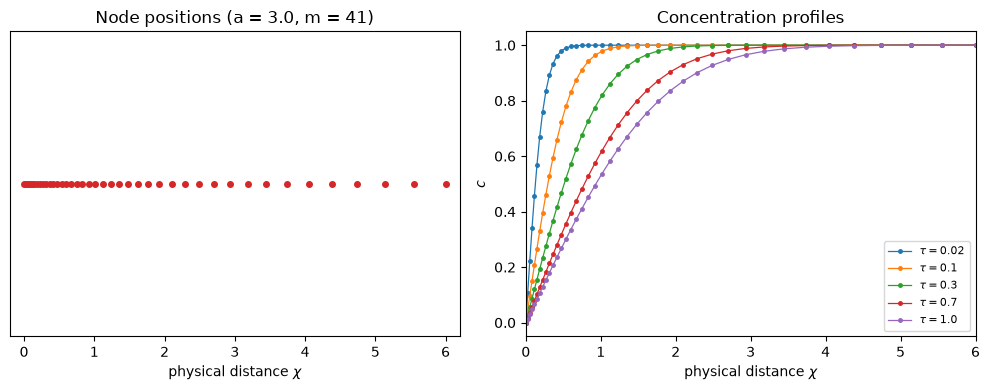

In [5]:
D_M = 4.0     # may be >> 0.5: the implicit scheme is unconditionally stable
n = 400
a = 3.0       # expansion factor

c_exp, m_exp, y_max = expanding_implicit_solve(D_M, n, a)
p = np.arange(m_exp)
y_p = p / (m_exp - 1) * y_max
chi_p = (np.exp(y_p) - 1.0) / a
print(f"a = {a},  y_max = {y_max:.4f},  m = {m_exp} (expanding),  "
      f"max |c| = {np.nanmax(np.abs(c_exp)):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
ax.plot(chi_p, np.zeros_like(chi_p), "o", ms=4, color="C3")
ax.set_xlabel(r"physical distance $\chi$"); ax.set_yticks([])
ax.set_title(f"Node positions (a = {a}, m = {m_exp})")
ax.set_xlim(-0.2, 6.2)

ax = axes[1]
tau = np.arange(n) / (n - 1)
for t in [0.02, 0.1, 0.3, 0.7, 1.0]:
    kc = int(round(t * (n - 1)))
    ax.plot(chi_p, c_exp[:, kc], "-o", ms=2.5, lw=0.9, label=fr"$\tau={t}$")
ax.set_xlabel(r"physical distance $\chi$"); ax.set_ylabel(r"$c$")
ax.set_title("Concentration profiles"); ax.set_xlim(0, 6); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Accuracy and node-count saving

We compare the expanding-grid current transient with the analytic Cottrell
result, and against a **uniform** implicit grid run at the same $D_M$ and $n$.
The uniform grid needs $m_{\text{uniform}}=1+\lceil 6\sqrt{D_M(n-1)}\rceil$ nodes;
the expanding grid reaches comparable accuracy with many fewer.

expanding grid : m =  41  mean rel err = 3.213e-03
uniform grid   : m = 241  mean rel err = 4.553e-03
node-count saving: 5.9x fewer spatial nodes


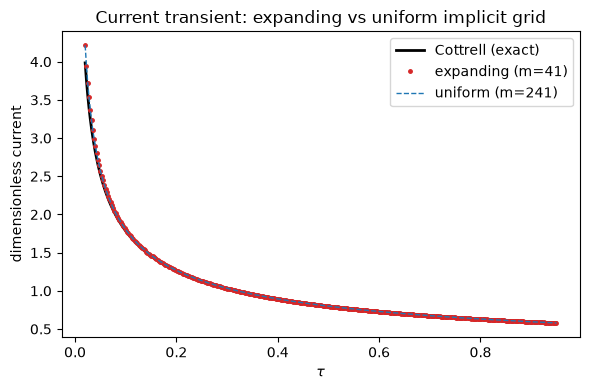

In [6]:
def uniform_implicit_solve(D_M, n, m=None):
    """Uniform-grid fully implicit reference solver."""
    if m is None:
        m = space_points(D_M, n)
    c = np.ones((m, n)); c[0, 1:] = 0.0; c[-1, 1:] = 1.0
    k_unk = m - 2
    sub = np.full(k_unk - 1, -D_M); sup = np.full(k_unk - 1, -D_M)
    diag = np.full(k_unk, 1.0 + 2.0 * D_M)
    for k in range(1, n):
        rhs = c[1:m - 1, k - 1].copy(); rhs[-1] += D_M
        c[1:m - 1, k] = tridiag_solve_banded(sub, diag, sup, rhs)
    return c

c_uni = uniform_implicit_solve(D_M, n)
m_uni = c_uni.shape[0]

i_exp = serm.electrode_current(c_exp, D_M)
i_uni = serm.electrode_current(c_uni, D_M)
i_cott = serm.cottrell_dimensionless(n)

win = (tau >= 0.02) & (tau <= 0.95)
mr_exp = float(np.nanmean(np.abs(i_exp[win] - i_cott[win]) / i_cott[win]))
mr_uni = float(np.nanmean(np.abs(i_uni[win] - i_cott[win]) / i_cott[win]))

print(f"expanding grid : m = {m_exp:3d}  mean rel err = {mr_exp:.3e}")
print(f"uniform grid   : m = {m_uni:3d}  mean rel err = {mr_uni:.3e}")
print(f"node-count saving: {m_uni / m_exp:.1f}x fewer spatial nodes")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tau[win], i_cott[win], "k-", lw=2, label="Cottrell (exact)")
ax.plot(tau[win], i_exp[win], "C3o", ms=2.5, label=f"expanding (m={m_exp})")
ax.plot(tau[win], i_uni[win], "C0--", lw=1, label=f"uniform (m={m_uni})")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("dimensionless current")
ax.set_title("Current transient: expanding vs uniform implicit grid")
ax.legend(); plt.tight_layout(); plt.show()

## Effect of the expansion factor

The expansion factor $a$ trades surface resolution against bulk coverage. Too
small and the grid is nearly uniform (no saving); too large and the bulk region
is under-resolved. We scan a few values and report the accuracy and node count.

In [7]:
print(f"{'a':>5} {'m':>5} {'mean rel err':>14}")
a_scan = [1.0, 2.0, 3.0, 5.0, 8.0]
errs_scan = []
for a_test in a_scan:
    c_t, m_t, _ = expanding_implicit_solve(D_M, n, a_test)
    i_t = serm.electrode_current(c_t, D_M)
    mr_t = float(np.nanmean(np.abs(i_t[win] - i_cott[win]) / i_cott[win]))
    errs_scan.append(mr_t)
    print(f"{a_test:5.1f} {m_t:5d} {mr_t:14.3e}")

    a     m   mean rel err
  1.0    79      4.386e-03
  2.0    53      3.727e-03
  3.0    41      3.213e-03
  5.0    29      5.437e-03
  8.0    21      1.551e-02


## Validation

Three assert-backed checks, strongest first per the project validation policy.

In [8]:
# --- Tier 1: closed-form analytic check (Cottrell) ---
assert mr_exp < 1e-2, mr_exp
print(f"PASS (Tier 1): expanding-grid current matches the analytic Cottrell "
      f"transient to {mr_exp:.2e} mean rel err.")

# --- Tier 3: efficiency / self-consistency vs the uniform implicit grid ---
# The expanding grid must (a) be at least as accurate as the uniform grid and
# (b) use strictly fewer spatial nodes -- the whole point of the method.
assert mr_exp <= mr_uni * 1.5, (mr_exp, mr_uni)   # comparable accuracy
assert m_exp < m_uni, (m_exp, m_uni)              # strictly fewer nodes
print(f"PASS (Tier 3): comparable accuracy to the uniform grid with "
      f"{m_uni / m_exp:.1f}x fewer nodes ({m_exp} vs {m_uni}).")

PASS (Tier 1): expanding-grid current matches the analytic Cottrell transient to 3.21e-03 mean rel err.
PASS (Tier 3): comparable accuracy to the uniform grid with 5.9x fewer nodes (41 vs 241).


In [9]:
# --- Tier 1 (bounds) + stability at large D_M ---
# Implicit scheme is unconditionally stable: solution stays in [0, 1] even at
# D_M = 4 (>> the explicit limit 0.5), and the surface value is driven to 0.
assert np.nanmax(c_exp) <= 1.0 + 1e-9, np.nanmax(c_exp)
assert np.nanmin(c_exp) >= -1e-9, np.nanmin(c_exp)
assert np.allclose(c_exp[0, 1:], 0.0), c_exp[0, 1:5]
# Expansion-factor scan: every tested a gives a usable (sub-2%) result.
assert max(errs_scan) < 2e-2, errs_scan
print("PASS (Tier 1/3): bounded, BC-consistent solution at D_M = 4; "
      "all scanned expansion factors give < 2% mean error.")

PASS (Tier 1/3): bounded, BC-consistent solution at D_M = 4; all scanned expansion factors give < 2% mean error.


## Summary

- An exponential change of variable $y=\ln(1+a\chi)$ maps a non-uniform
  physical grid (dense at the electrode) to a **uniform $y$-grid**, turning
  Fick's law into a diffusion equation with a position-dependent model
  coefficient $D_p=D_M e^{-2y_p}$ and a small drift term ($\pm\alpha$).
- The fully implicit scheme on this grid stays tridiagonal, so the solver cost
  per step is essentially unchanged.
- It reaches Cottrell-level accuracy with **several times fewer spatial nodes**
  than a uniform implicit grid, the key speed advantage for large simulations
  (e.g. AC voltammetry, Chapter 7).
- The expansion factor $a$ is the tuning knob: moderate values (here $a\approx3$)
  give the best accuracy/node trade-off.

<!-- nav-footer -->

---

[← Chapter 3 — Speed and Accuracy: Implicit and Weighted Finite-Difference Schemes](../03_speed_and_accuracy.ipynb)

[Contents (README)](../../README.md)